In [1]:
import sys
import os
sys.path.append('/home/apassi1/deepbottleneck')
from calc_encoding import load_encoding_results
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

/home/apassi1/.conda/envs/backprop_pca/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/apassi1/.conda/envs/backprop_pca/lib/python3.12/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/apassi1/.conda/envs/backprop_pca/lib/python3.12/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/apassi1/.conda/envs/backprop_pca/lib/python3

In [2]:
encoding_label = 'all_subjects_figure4'
df = load_encoding_results(encoding_label=encoding_label)
df = df[df['roi'] == "ventral visual stream"]

In [3]:
label_mapping = {
    'lr0.001_randomFalse_staticNormTrue_100k_freezeBefore1': 'PCA model',
    'lr0.001_randomTrue_staticNormTrue_100kRand_freezeBefore1': 'random model'  
}

df['model_label'] = df['model_label'].replace(label_mapping)
df['training_samples'] = (df['ckpt_epoch'] / 391) * 50000
df['epochs'] = (df['ckpt_epoch'] / 391)

In [4]:
df['training_samples'] = pd.to_numeric(df['training_samples'], errors='coerce')
mask = df['model_label'] == 'PCA model'
df.loc[mask, 'training_samples'] += 100_000

In [5]:
# Define two distinct palettes: warm for classification accuracy and cool for encoding score
classification_palette = sns.color_palette("autumn", 2)  # warm colors (e.g., oranges and reds)
encoding_palette = sns.color_palette("winter", 2)          # cool colors (e.g., blues and purples)

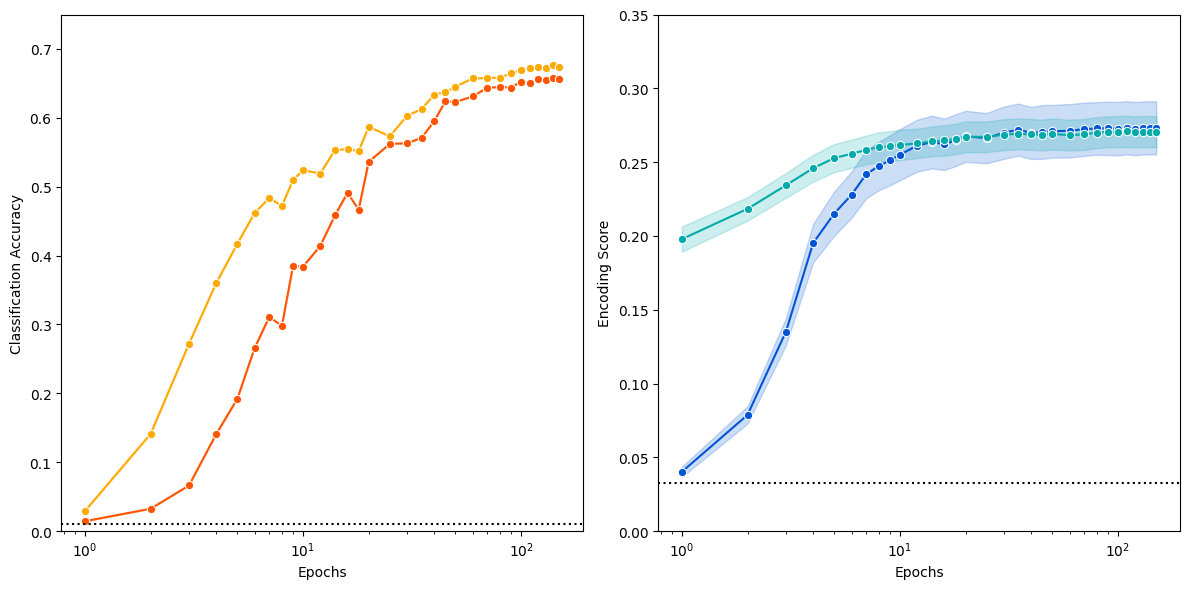

In [6]:
df_nonzero = df[df['ckpt_epoch'] != 0] # Filter out rows with ckpt_epoch == 0 
# df_encoding = df_nonzero[df_nonzero['layerid'] == 10] # filter for layer 10

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)

# Plot classification accuracy using the warm classification_palette
sns.lineplot(
    data=df_nonzero,
    x='epochs',
    y='eval_accuracy',
    hue='model_label',
    marker='o',
    hue_order=['random model', 'PCA model'],
    ax=axes[0],
    palette=classification_palette
)
# Plot horizontal line for chance performance of miniImageNet (assumed to be 20%)
chance_performance = 0.01
axes[0].axhline(y=chance_performance, linestyle=':', color='black', label='Chance performance')
axes[0].set(xscale='log', ylim=(0, 0.75), ylabel='Classification Accuracy', xlabel='Epochs')
# Remove legend for the first plot (if it exists)
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()

# Plot encoding score for layer 10 using the cool encoding_palette
sns.lineplot(
    data=df_nonzero,
    x='epochs',
    y='encoding_score',
    hue='model_label',
    marker='o',
    hue_order=['random model', 'PCA model'],
    ax=axes[1],
    palette=encoding_palette,
    errorbar="se",  # Using standard error of the mean
)
# Compute the baseline encoding score for random model at ckpt_epoch == 0 for layer 10
baseline_encoding = df[(df['ckpt_epoch'] == 0) & 
                         (df['model_label'] == 'random model') & 
                         (df['layerid'] == 10)]['encoding_score'].mean()
axes[1].axhline(y=baseline_encoding, linestyle=':', color='black', label='random model without supervision')
axes[1].set(xscale='log', ylim=(0, 0.35), ylabel='Encoding Score', xlabel='Epochs')
# Remove legend for the second plot (if it exists)
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()

plt.tight_layout()
plt.show()

In [7]:
baseline_encoding = df[(df['ckpt_epoch'] == 0) & 
                         (df['model_label'] == 'random model') & 
                         (df['layerid'] == 10)]['encoding_score']

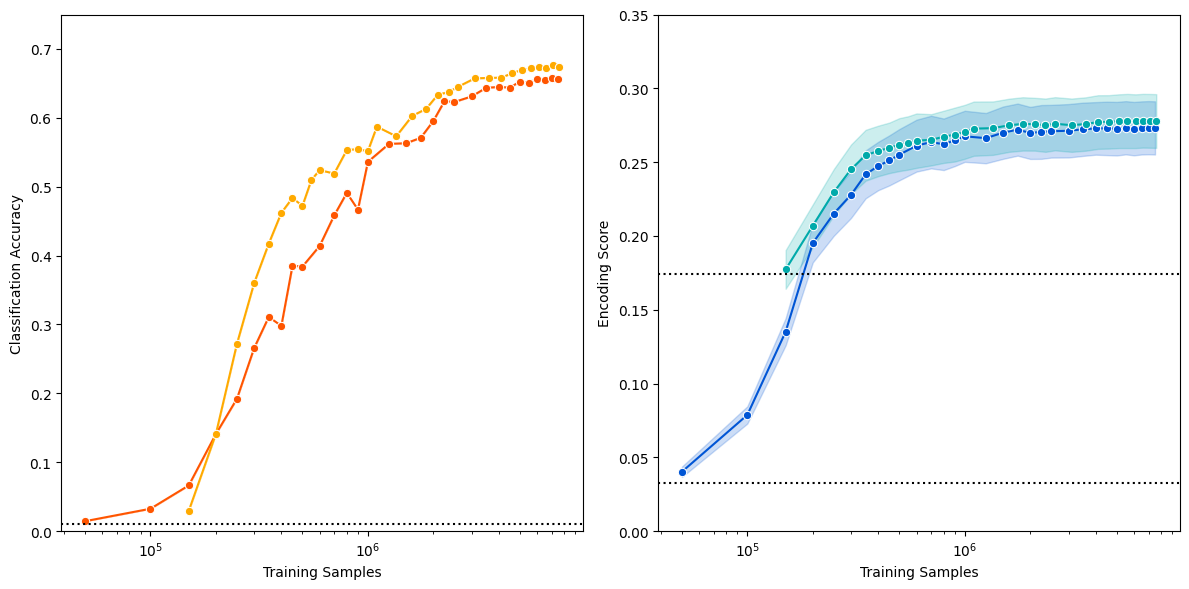

In [8]:
# Filter out rows with ckpt_epoch == 0 for the line plots
df_nonzero = df[df['ckpt_epoch'] != 0]

# Further filter for layer 10 for the encoding score plot
df_encoding = df_nonzero[df_nonzero['layerid'] == 10]

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True)

# Plot classification accuracy using the warm classification_palette
sns.lineplot(
    data=df_nonzero,
    x='training_samples',
    y='eval_accuracy',
    hue='model_label',
    marker='o',
    hue_order=['random model', 'PCA model'],
    ax=axes[0],
    palette=classification_palette
)
# Plot horizontal line for chance performance of miniImageNet (assumed to be 20%)
chance_performance = 0.01
axes[0].axhline(y=chance_performance, linestyle=':', color='black', label='Chance performance')
axes[0].set(xscale='log', ylim=(0, 0.75), ylabel='Classification Accuracy', xlabel='Training Samples')
# Remove legend for the first plot (if it exists)
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()

# Plot encoding score for layer 10 using the cool encoding_palette
sns.lineplot(
    data=df_encoding,
    x='training_samples',
    y='encoding_score',
    hue='model_label',
    marker='o',
    hue_order=['random model', 'PCA model'],
    ax=axes[1],
    palette=encoding_palette,
    errorbar="se",  # Using standard error of the mean
)
# Compute the baseline encoding score for random model at ckpt_epoch == 0 for layer 10
baseline_encoding_random = df[(df['ckpt_epoch'] == 0) & 
                                (df['model_label'] == 'random model') & 
                                (df['layerid'] == 10)]['encoding_score'].mean()
axes[1].axhline(y=baseline_encoding_random, linestyle=':', color='black', label='random model without supervision')

# Compute the baseline encoding score for PCA model at ckpt_epoch == 0 for layer 10
baseline_encoding_pca = df[(df['ckpt_epoch'] == 0) & 
                           (df['model_label'] == 'PCA model') & 
                           (df['layerid'] == 10)]['encoding_score'].mean()
axes[1].axhline(y=baseline_encoding_pca, linestyle=':', color='black', label='PCA model without supervision')

axes[1].set(xscale='log', ylim=(0, 0.35), ylabel='Encoding Score', xlabel='Training Samples')
# Remove legend for the second plot (if it exists)
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()

plt.tight_layout()
plt.show()

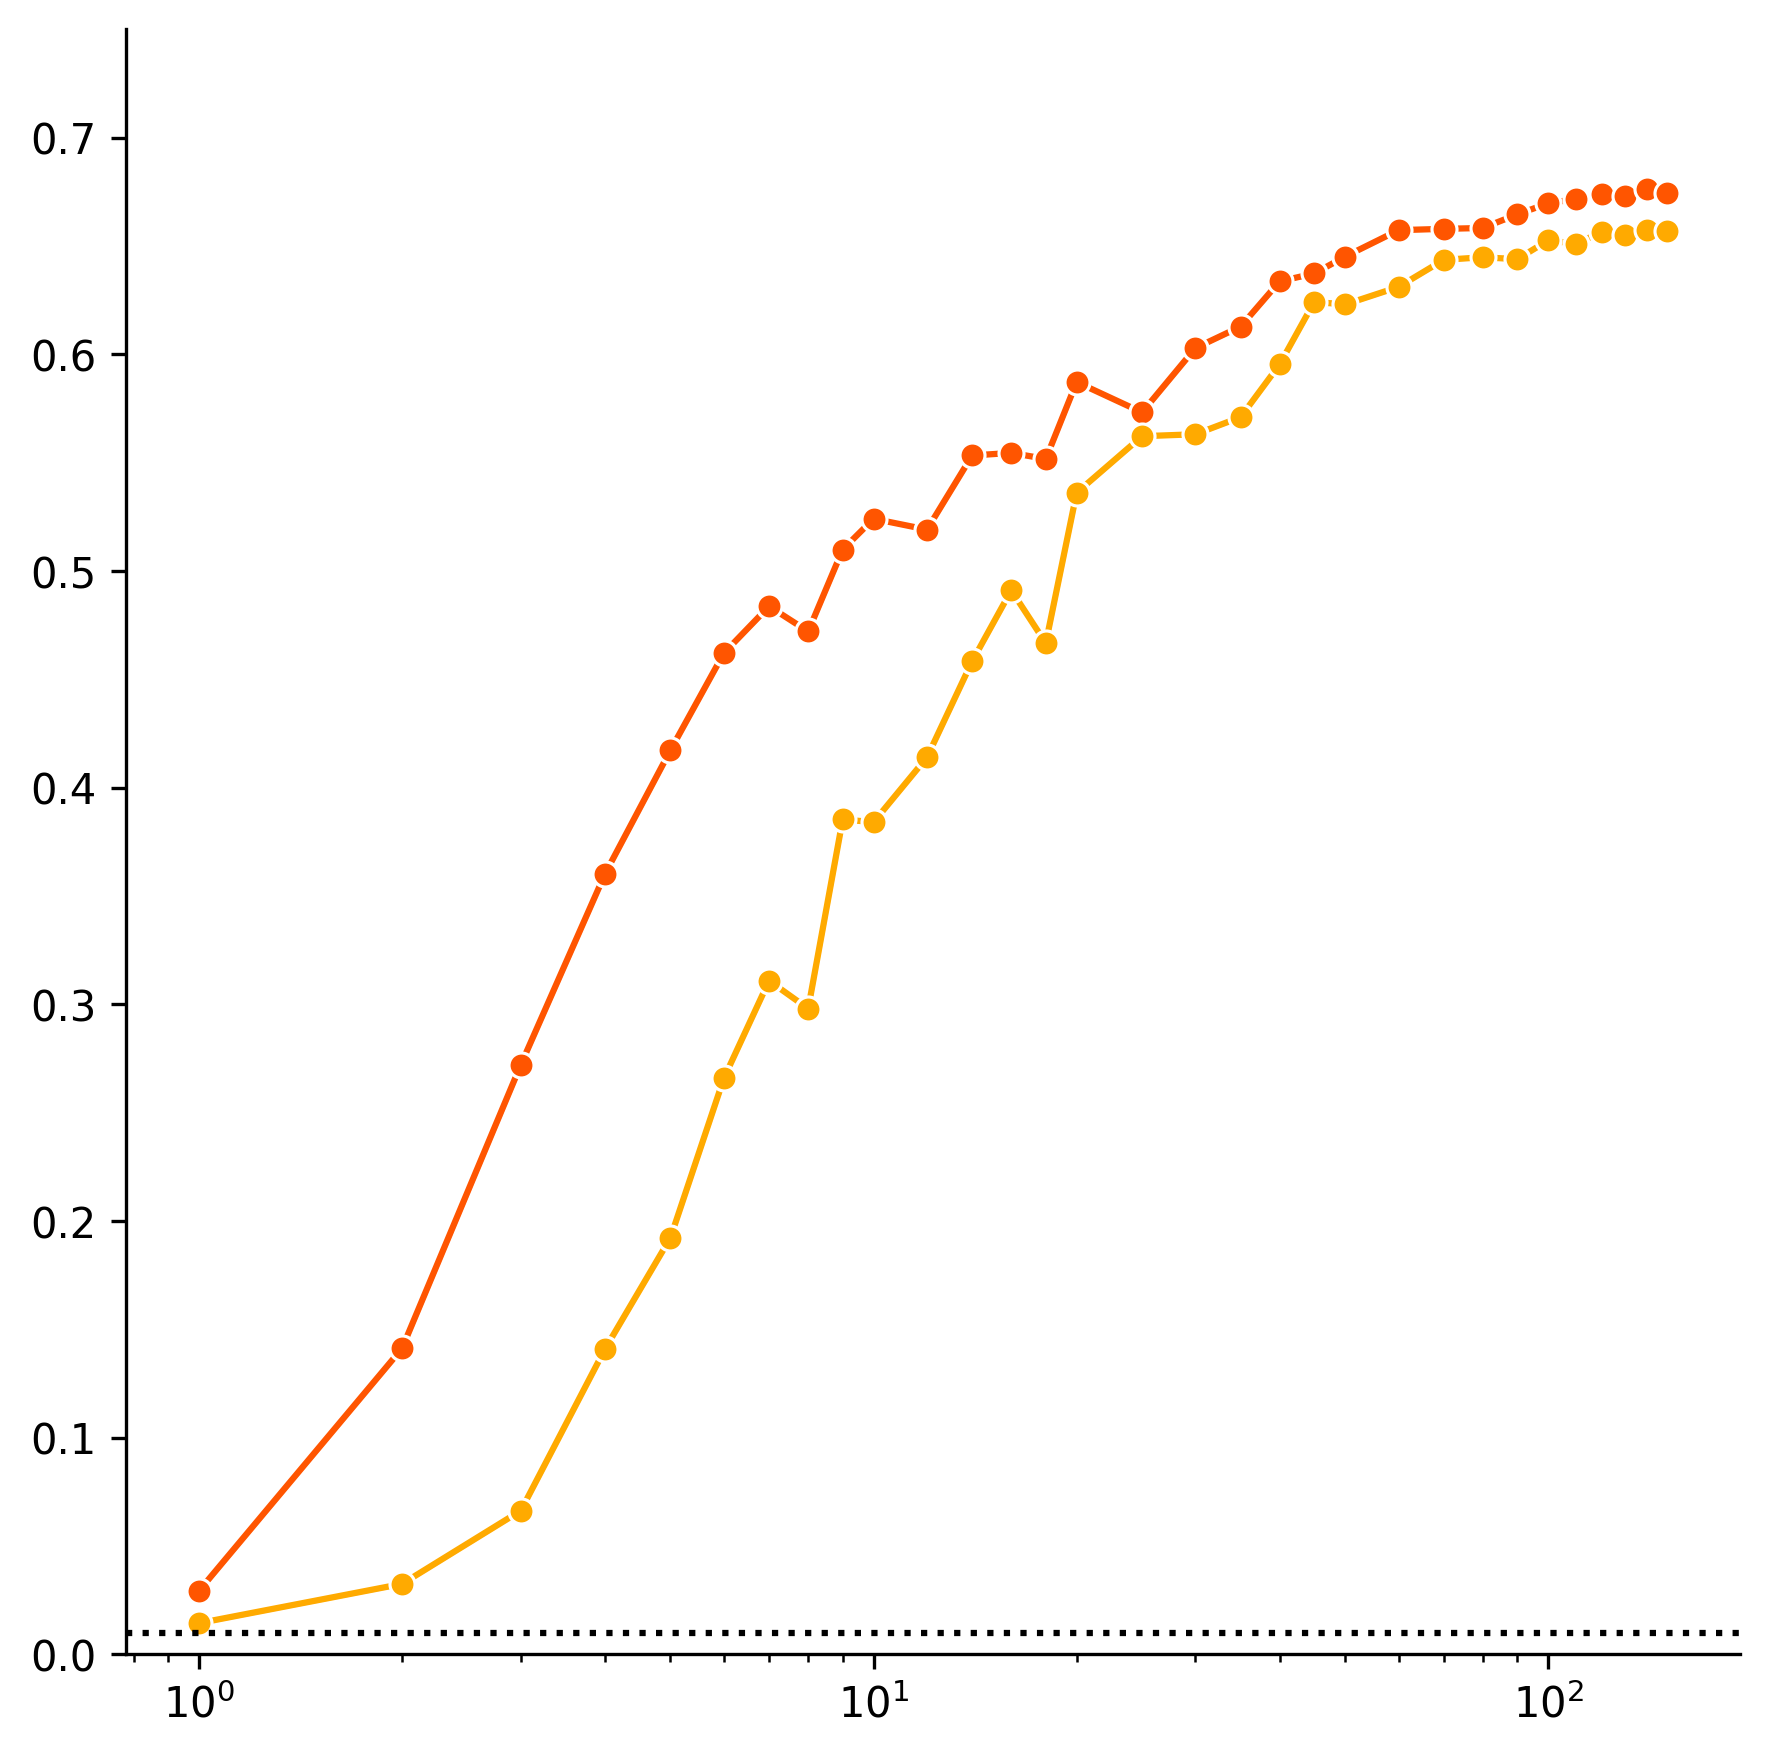

In [9]:
df_nonzero = df[df['ckpt_epoch'] != 0]
df_encoding = df_nonzero[df_nonzero['layerid'] == 10]

# === Classification Accuracy Plot ===
plt.figure(figsize=(6, 6))
g = sns.lineplot(
    data=df_nonzero,
    x='epochs',
    y='eval_accuracy',
    hue='model_label',
    marker='o',
    hue_order=['PCA model', 'random model'],
    palette=classification_palette,
)

# Horizontal line for chance performance (1%)
chance_performance = 0.01
plt.axhline(y=chance_performance, linestyle=':', color='black', label='Chance performance')

plt.xscale('log')
plt.ylim(0, 0.75)
plt.xlabel('')
plt.ylabel('')

# Clean up spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Remove legend if it exists
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.tight_layout()
g.figure.set_dpi(300)  # or 200, 300, etc.
plt.show()

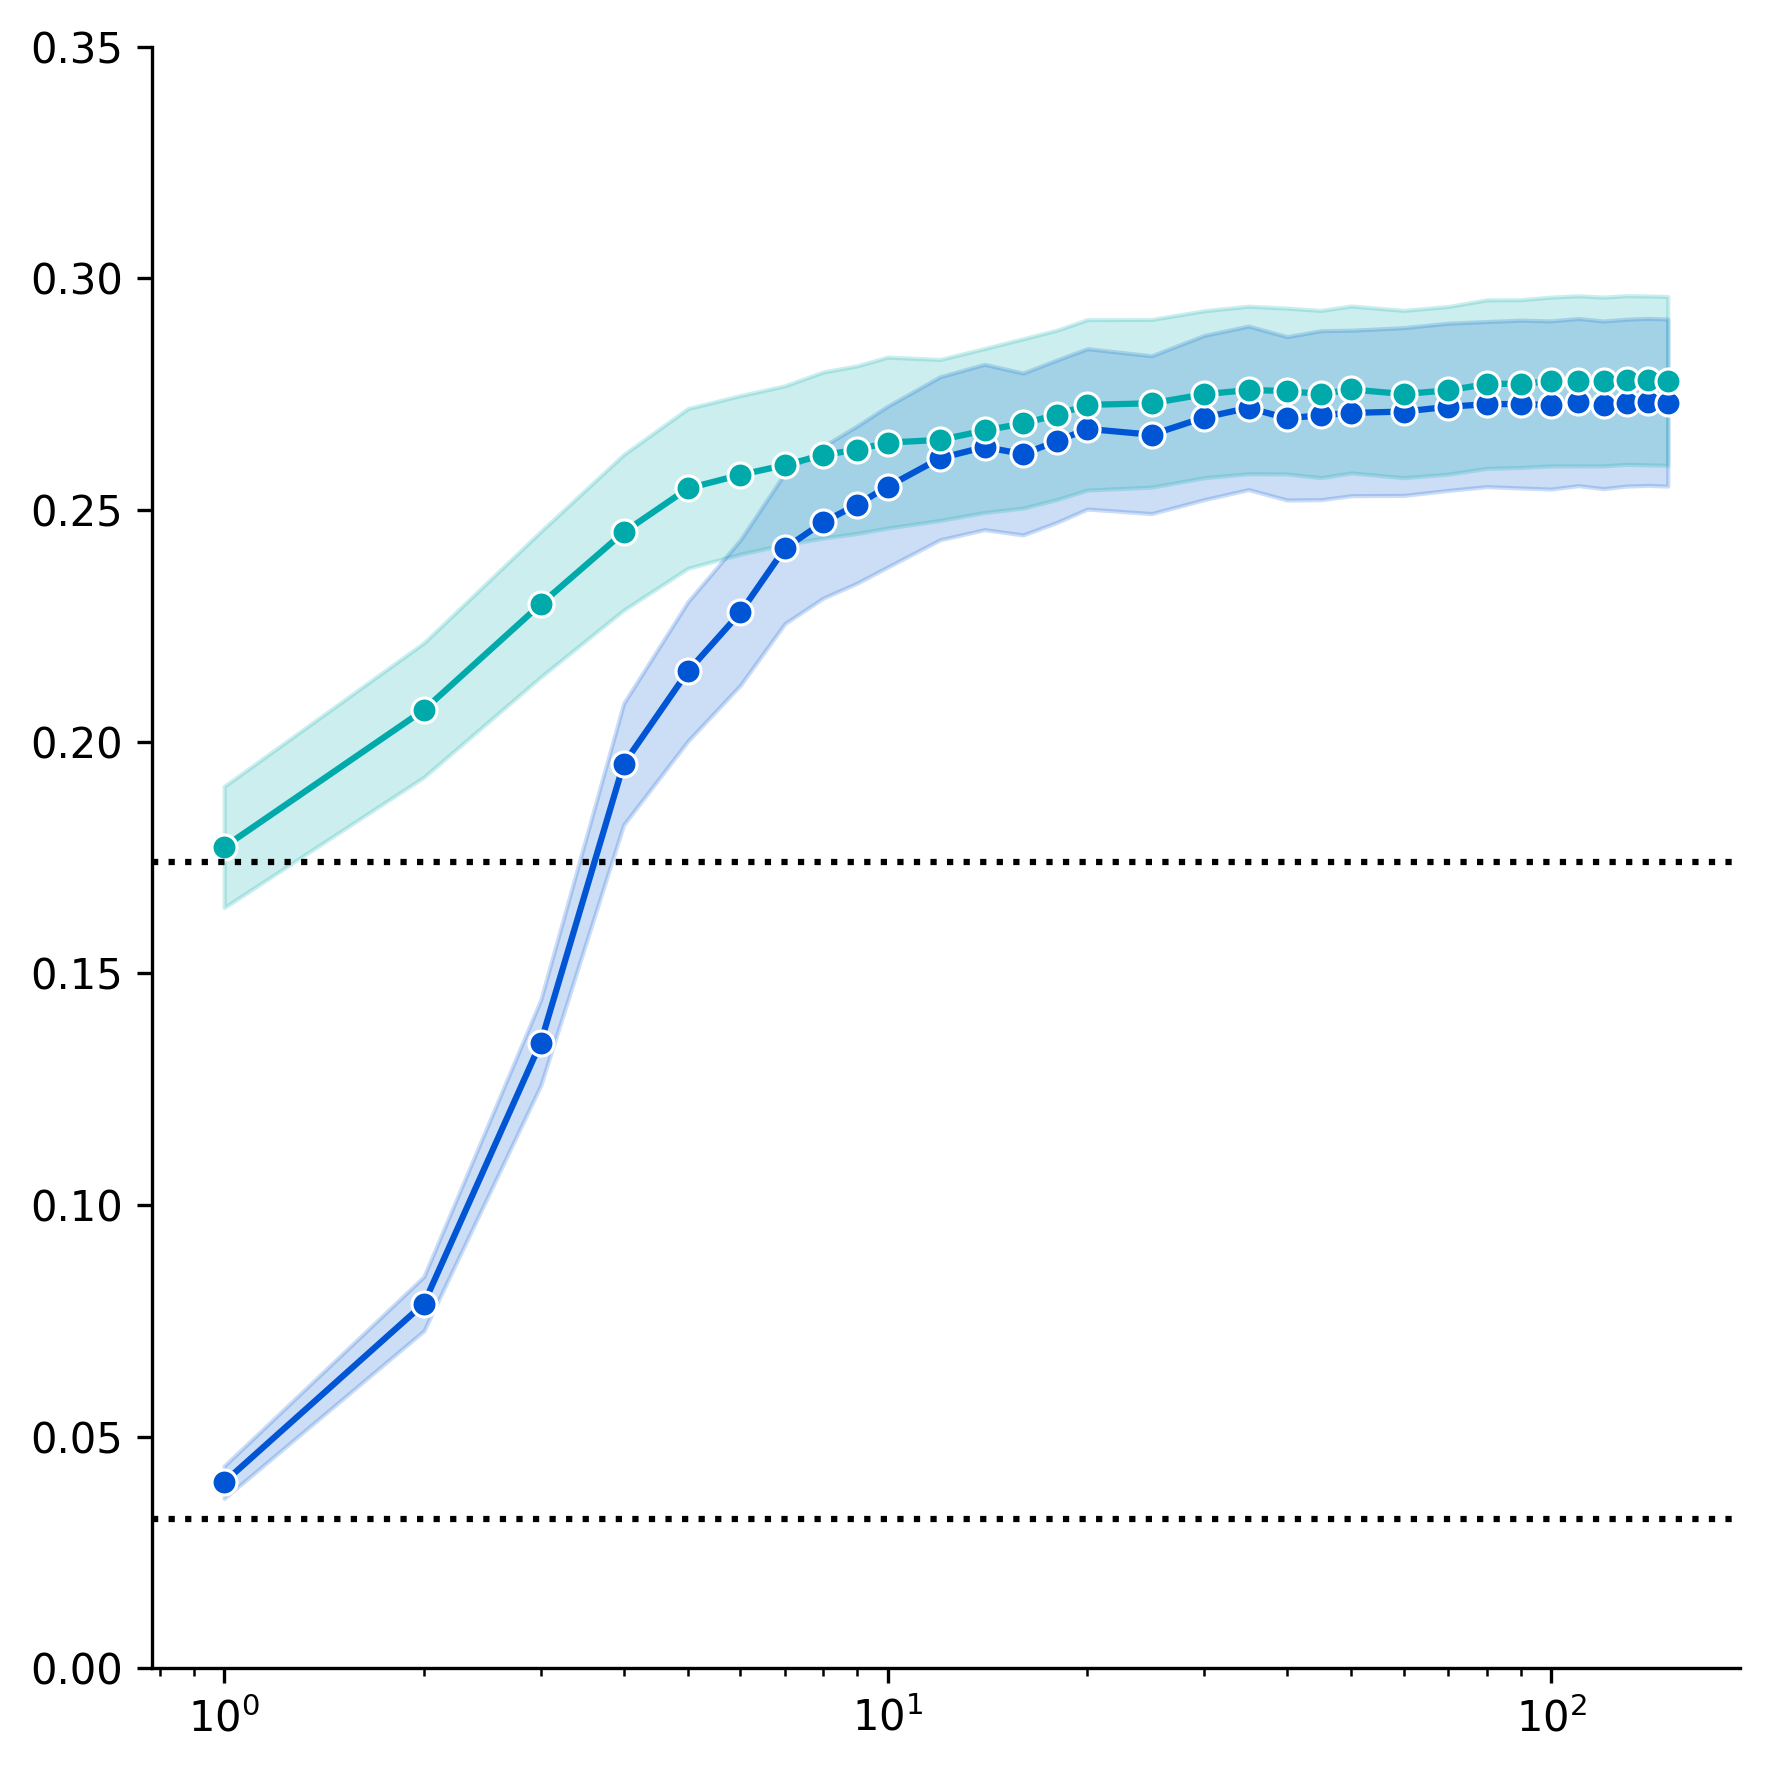

: 

In [ ]:
# === Encoding Score Plot (Layer 10) ===
plt.figure(figsize=(6, 6))
g = sns.lineplot(
    data=df_encoding,
    x='epochs',
    y='encoding_score',
    hue='model_label',
    marker='o',
    # hue_order=['random model'],
    hue_order=['random model', 'PCA model'],
    palette=encoding_palette,
    errorbar="se",  # Using standard error of the mean
)

# Baseline encoding scores from ckpt_epoch == 0, layer 10
baseline_encoding_random = df[
    (df['ckpt_epoch'] == 0) &
    (df['model_label'] == 'random model') &
    (df['layerid'] == 10)
]['encoding_score'].mean()

baseline_encoding_pca = df[
    (df['ckpt_epoch'] == 0) &
    (df['model_label'] == 'PCA model') &
    (df['layerid'] == 10)
]['encoding_score'].mean()

plt.axhline(y=baseline_encoding_random, linestyle=':', color='black', label='random model without supervision')
plt.axhline(y=baseline_encoding_pca, linestyle=':', color='black', label='PCA model without supervision')

plt.xscale('log')
plt.ylim(0, 0.35)
plt.xlabel('')
plt.ylabel('')

# Clean up spines
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Remove legend if it exists
if ax.get_legend() is not None:
    ax.get_legend().remove()

g.figure.set_dpi(300)  # or 200, 300, etc.
plt.tight_layout()
plt.show()